# Prédiction de la Conflictualité des Variants Génétiques

> **Projet ML — M1 DTA/IA** | Mahé Begnis | Avril 2026

**Objectif** : prédire si un variant aura des classifications contradictoires entre labos.
**Cible** : `CLASS` ∈ {0=concordant, 1=conflictuel}

## 1. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, f1_score, matthews_corrcoef, make_scorer,
                             accuracy_score, confusion_matrix, roc_curve,
                             average_precision_score, brier_score_loss)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import shap
import pickle, time, warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.figsize': (12,6), 'font.size': 11, 'figure.dpi': 100})
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Imports OK')

Imports OK


## 2. Chargement et feature engineering (base + spécifique conflictualité)

In [2]:
# Chargement
df = pd.read_csv('data/clinvar_conflicting.csv', low_memory=False)
TARGET = 'CLASS'
print(f'Dataset : {df.shape[0]} x {df.shape[1]}')
print(f'CLASS : {df[TARGET].value_counts().to_dict()}')

# FE de base (identique pathogenicite)
sift_map = {'tolerated':0,'tolerated_low_confidence':1,'deleterious_low_confidence':2,'deleterious':3}
polyphen_map = {'benign':0,'possibly_damaging':1,'probably_damaging':2,'unknown':np.nan}
impact_map = {'MODIFIER':0,'LOW':1,'MODERATE':2,'HIGH':3}
df['SIFT_encoded'] = df['SIFT'].map(sift_map)
df['PolyPhen_encoded'] = df['PolyPhen'].map(polyphen_map)
df['IMPACT_encoded'] = df['IMPACT'].map(impact_map)
df['has_SIFT'] = (~df['SIFT'].isna()).astype(int)
df['has_PolyPhen'] = (~df['PolyPhen'].isna()).astype(int)
df['is_exonic'] = (~df['EXON'].isna()).astype(int)
df['is_intronic'] = (~df['INTRON'].isna()).astype(int)
chrom_map = {str(i):i for i in range(1,23)}
chrom_map.update({'X':23,'Y':24})
df['CHROM_encoded'] = df['CHROM'].map(chrom_map)
top_csq = df['Consequence'].value_counts().head(10).index.tolist()
df['Consequence_grouped'] = df['Consequence'].where(df['Consequence'].isin(top_csq), 'other')
epsilon = 1e-8
for col in ['AF_ESP','AF_EXAC','AF_TGP']:
    df[f'{col}_log'] = np.log10(df[col] + epsilon)
df['is_rare'] = ((df['AF_ESP']==0)&(df['AF_EXAC']==0)&(df['AF_TGP']==0)).astype(int)

# FE specifique conflictualite
df['af_disagreement'] = df[['AF_ESP','AF_EXAC','AF_TGP']].std(axis=1)
df['cadd_ambiguity'] = -np.abs(df['CADD_PHRED'] - 17.5)
df['is_missense'] = df['Consequence'].str.contains('missense', case=False, na=False).astype(int)

# n_submitters (jointure variant_summary)
vs = pd.read_csv('data/variant_summary.txt.gz', sep='\t', compression='gzip',
                 usecols=['Assembly','Chromosome','Start','ReferenceAlleleVCF',
                          'AlternateAlleleVCF','NumberSubmitters'], dtype=str, low_memory=False)
vs = vs[vs['Assembly'] == 'GRCh37']
df['join_key'] = df['CHROM'].astype(str)+'_'+df['POS'].astype(str)+'_'+df['REF']+'_'+df['ALT']
vs['join_key'] = vs['Chromosome']+'_'+vs['Start']+'_'+vs['ReferenceAlleleVCF']+'_'+vs['AlternateAlleleVCF']
vs_dedup = vs.drop_duplicates(subset='join_key', keep='first')
df = df.merge(vs_dedup[['join_key','NumberSubmitters']], on='join_key', how='left')
df['n_submitters'] = pd.to_numeric(df['NumberSubmitters'], errors='coerce')
del vs, vs_dedup

print(f'af_disagreement mean={df["af_disagreement"].mean():.6f}')
print(f'cadd_ambiguity  mean={df["cadd_ambiguity"].dropna().mean():.2f}')
print(f'is_missense     {df["is_missense"].sum()} ({df["is_missense"].mean()*100:.1f}%)')
print(f'n_submitters    mean={df["n_submitters"].dropna().mean():.1f}')

Dataset : 65188 x 46
CLASS : {0: 48754, 1: 16434}


af_disagreement mean=0.005188
cadd_ambiguity  mean=-9.44
is_missense     32408 (49.7%)
n_submitters    mean=8.1


## 3. Analyse bivariée — pouvoir discriminant des features

In [3]:
# Mann-Whitney U sur toutes les features
test_cols = ['AF_ESP','AF_EXAC','AF_TGP','CADD_PHRED','BLOSUM62','LoFtool',
             'SIFT_encoded','PolyPhen_encoded','IMPACT_encoded',
             'is_exonic','is_rare','has_SIFT',
             'af_disagreement','cadd_ambiguity','is_missense','n_submitters']
alpha_bonf = 0.05 / len(test_cols)

print(f'MANN-WHITNEY U — CONFLICTUALITE (alpha_bonf={alpha_bonf:.5f})')
print('='*85)
print(f'{"Variable":25s} | {"p-value":>12s} | {"eta2":>8s} | {"mean_0":>10s} | {"mean_1":>10s} | Sig')
print('-'*85)

mw = []
for col in test_cols:
    d0 = df[df[TARGET]==0][col].dropna()
    d1 = df[df[TARGET]==1][col].dropna()
    if len(d0)==0 or len(d1)==0: continue
    u, p = stats.mannwhitneyu(d0, d1, alternative='two-sided')
    gm = df[col].dropna().mean()
    sst = ((df[col].dropna()-gm)**2).sum()
    ssb = len(d0)*(d0.mean()-gm)**2 + len(d1)*(d1.mean()-gm)**2
    eta2 = ssb/sst if sst>0 else 0
    sig = 'OUI ***' if p < alpha_bonf else 'NON'
    print(f'  {col:23s} | {p:12.2e} | {eta2:8.4f} | {d0.mean():10.4f} | {d1.mean():10.4f} | {sig}')
    mw.append({'feat':col,'eta2':eta2,'p':p,'sig':p<alpha_bonf})

mw_df = pd.DataFrame(mw).sort_values('eta2', ascending=False)
print(f'\nTop par eta2 :')
for _, r in mw_df.head(8).iterrows():
    print(f'  {r["feat"]:25s} | eta2={r["eta2"]:.4f}')

MANN-WHITNEY U — CONFLICTUALITE (alpha_bonf=0.00313)
Variable                  |      p-value |     eta2 |     mean_0 |     mean_1 | Sig
-------------------------------------------------------------------------------------
  AF_ESP                  |     1.03e-12 |   0.0160 |     0.0188 |     0.0019 | OUI ***
  AF_EXAC                 |     5.30e-90 |   0.0147 |     0.0187 |     0.0021 | OUI ***
  AF_TGP                  |     1.33e-02 |   0.0169 |     0.0198 |     0.0019 | NON
  CADD_PHRED              |     1.14e-14 |   0.0014 |    15.9243 |    14.9859 | OUI ***
  BLOSUM62                |     8.94e-01 |   0.0000 |    -0.4040 |    -0.3973 | NON
  LoFtool                 |     9.55e-01 |   0.0000 |     0.3450 |     0.3451 | NON
  SIFT_encoded            |     8.36e-01 |   0.0000 |     1.4958 |     1.4924 | NON
  PolyPhen_encoded        |     8.78e-01 |   0.0000 |     0.7657 |     0.7674 | NON
  IMPACT_encoded          |     1.45e-52 |   0.0041 |     1.5976 |     1.4867 | OUI ***
  is_

  is_missense             |     5.43e-13 |   0.0008 |     0.4889 |     0.5215 | OUI ***


  n_submitters            |     2.36e-07 |   0.0016 |     8.0060 |     8.4512 | OUI ***

Top par eta2 :
  is_rare                   | eta2=0.0226
  AF_TGP                    | eta2=0.0169
  AF_ESP                    | eta2=0.0160
  AF_EXAC                   | eta2=0.0147
  af_disagreement           | eta2=0.0097
  IMPACT_encoded            | eta2=0.0041
  cadd_ambiguity            | eta2=0.0021
  n_submitters              | eta2=0.0016


## 4. Dataset final et split

In [4]:
num_features = ['AF_ESP','AF_EXAC','AF_TGP','AF_ESP_log','AF_EXAC_log','AF_TGP_log',
    'CADD_PHRED','BLOSUM62','LoFtool','SIFT_encoded','PolyPhen_encoded',
    'IMPACT_encoded','CHROM_encoded','STRAND','ORIGIN',
    'af_disagreement','cadd_ambiguity','n_submitters']
bin_features = ['is_exonic','is_intronic','is_rare','has_SIFT','has_PolyPhen','is_missense']
cat_features = ['Consequence_grouped','CLNVC']

df_model = df[num_features + bin_features + cat_features + [TARGET]].copy()
for c in cat_features: df_model[c] = df_model[c].fillna('missing').astype(str)
X = df_model.drop(columns=[TARGET]); y = df_model[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
scale_pos = (y_train==0).sum() / (y_train==1).sum()

print(f'Features : {X.shape[1]}')
print(f'Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')
print(f'scale_pos_weight = {scale_pos:.2f}')

cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()
preprocessor = ColumnTransformer([
    ('num', Pipeline([('imp',SimpleImputer(strategy='median')),('scl',StandardScaler())]), num_cols),
    ('cat', Pipeline([('enc',OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)])

X_train_gbm = pd.get_dummies(X_train, columns=cat_cols, drop_first=False)
X_test_gbm = pd.get_dummies(X_test, columns=cat_cols, drop_first=False)
X_train_gbm, X_test_gbm = X_train_gbm.align(X_test_gbm, join='left', axis=1, fill_value=0)
X_train_cat = X_train.copy(); X_test_cat = X_test.copy()
cat_idx = [X_train_cat.columns.get_loc(c) for c in cat_cols]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'AUC':'roc_auc','F1':make_scorer(f1_score),'MCC':make_scorer(matthews_corrcoef),'Accuracy':'accuracy'}
print(f'GBM features : {X_train_gbm.shape[1]}')

Features : 26
Train : 52150 | Test : 13038
scale_pos_weight = 2.97
GBM features : 42


## 5. Baselines + Random Forest

In [5]:
baselines = {
    'LogReg_L2': Pipeline([('p',preprocessor),('c',LogisticRegression(penalty='l2',C=1.0,class_weight='balanced',solver='saga',max_iter=5000,random_state=RANDOM_STATE))]),
    'LogReg_L1': Pipeline([('p',preprocessor),('c',LogisticRegression(penalty='l1',C=1.0,class_weight='balanced',solver='saga',max_iter=5000,random_state=RANDOM_STATE))]),
    'KNN_5': Pipeline([('p',preprocessor),('c',KNeighborsClassifier(n_neighbors=5,weights='distance',n_jobs=-1))]),
    'SVM_RBF': Pipeline([('p',preprocessor),('c',SVC(kernel='rbf',C=1.0,gamma='scale',class_weight='balanced',probability=True,random_state=RANDOM_STATE))]),
}
rf_pipe = Pipeline([('p',preprocessor),('c',RandomForestClassifier(n_estimators=500,max_features='sqrt',min_samples_leaf=2,class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1))])

results = {}
for name, pipe in {**baselines, 'RandomForest': rf_pipe}.items():
    t0 = time.time()
    cv = cross_validate(pipe, X_train, y_train, cv=skf, scoring=scoring, return_train_score=True, n_jobs=-1)
    elapsed = time.time() - t0
    results[name] = {
        'AUC_mean':cv['test_AUC'].mean(),'AUC_std':cv['test_AUC'].std(),
        'F1_mean':cv['test_F1'].mean(),'F1_std':cv['test_F1'].std(),
        'MCC_mean':cv['test_MCC'].mean(),'MCC_std':cv['test_MCC'].std(),
        'Acc_mean':cv['test_Accuracy'].mean(),'Acc_std':cv['test_Accuracy'].std(),
        'AUC_train':cv['train_AUC'].mean(),'time':elapsed}
    r = results[name]; gap = r['AUC_train']-r['AUC_mean']
    print(f"{name:15s} | AUC={r['AUC_mean']:.4f}±{r['AUC_std']:.4f} | F1={r['F1_mean']:.4f} | MCC={r['MCC_mean']:.4f} | gap={gap:.4f} | {elapsed:.1f}s")

LogReg_L2       | AUC=0.7177±0.0058 | F1=0.4942 | MCC=0.2753 | gap=0.0019 | 11.4s


LogReg_L1       | AUC=0.7178±0.0058 | F1=0.4944 | MCC=0.2756 | gap=0.0018 | 15.0s


KNN_5           | AUC=0.6851±0.0043 | F1=0.3736 | MCC=0.2129 | gap=0.3148 | 9.5s


SVM_RBF         | AUC=0.7548±0.0040 | F1=0.5293 | MCC=0.3350 | gap=0.0193 | 402.7s


RandomForest    | AUC=0.7781±0.0021 | F1=0.5018 | MCC=0.3450 | gap=0.2191 | 12.1s


## 6. Gradient Boosting (XGBoost, LightGBM, CatBoost)

In [6]:
def eval_gbm(cls, params, X, y, skf, fp=None, catboost=False, ci=None):
    oof_p = np.zeros(len(y)); oof_c = np.zeros(len(y),dtype=int); ta = []; bi = []
    for ti, vi in skf.split(X, y):
        Xt=X.iloc[ti]; Xv=X.iloc[vi]; yt=y.iloc[ti]; yv=y.iloc[vi]
        m = cls(**params)
        if catboost: m.fit(Xt,yt,eval_set=(Xv,yv),cat_features=ci,early_stopping_rounds=50,verbose=0)
        else: m.fit(Xt,yt,eval_set=[(Xv,yv)],**(fp or {}))
        bi.append(getattr(m,'best_iteration_',getattr(m,'best_iteration',params.get('n_estimators','?'))))
        oof_p[vi]=m.predict_proba(Xv)[:,1]; oof_c[vi]=m.predict(Xv)
        ta.append(roc_auc_score(yt,m.predict_proba(Xt)[:,1]))
    return {'AUC_mean':roc_auc_score(y,oof_p),'AUC_std':0,'F1_mean':f1_score(y,oof_c),'F1_std':0,
            'MCC_mean':matthews_corrcoef(y,oof_c),'MCC_std':0,'Acc_mean':accuracy_score(y,oof_c),'Acc_std':0,
            'AUC_train':np.mean(ta),'best_iters':bi,'oof_p':oof_p,'oof_c':oof_c}

# XGBoost
t0=time.time()
xr=eval_gbm(xgb.XGBClassifier,{'n_estimators':5000,'learning_rate':0.05,'max_depth':6,'subsample':0.8,
    'colsample_bytree':0.8,'reg_alpha':0.1,'reg_lambda':1.0,'scale_pos_weight':scale_pos,
    'eval_metric':'auc','early_stopping_rounds':50,'random_state':RANDOM_STATE,'n_jobs':-1,'verbosity':0},
    X_train_gbm,y_train,skf,fp={'verbose':False})
xr['time']=time.time()-t0; results['XGBoost']=xr
print(f"XGBoost  | AUC={xr['AUC_mean']:.4f} | F1={xr['F1_mean']:.4f} | iters={xr['best_iters']} | {xr['time']:.1f}s")

# ============================================================
# LightGBM — CORRIGE
# ============================================================
# Diagnostic du bug initial : avec lr=0.05 et num_leaves=31, LightGBM convergeait
# en 12 iterations vers un modele trivial (predit toujours 0).
# Cause : la leaf-wise growth avec peu de signal (eta2 < 3%) et un learning rate
# trop eleve fait que le modele atteint un plateau de logloss tres vite.
#
# Corrections appliquees :
# 1. learning_rate=0.01 (au lieu de 0.05) → donne plus de temps au modele
# 2. metric='auc' pour l'early stopping (au lieu de logloss par defaut)
#    → force le modele a ameliorer la discrimination, pas juste la loss
# 3. min_child_samples=50 → evite les splits trop specifiques sur peu d'echantillons
# 4. num_leaves=63 → plus de capacite pour capturer des interactions subtiles

t0=time.time()
lr=eval_gbm(lgb.LGBMClassifier,{'n_estimators':5000,'learning_rate':0.01,'num_leaves':63,'max_depth':-1,
    'subsample':0.8,'colsample_bytree':0.8,'reg_alpha':0.1,'reg_lambda':1.0,
    'scale_pos_weight':scale_pos,'min_child_samples':50,
    'random_state':RANDOM_STATE,'n_jobs':-1,'verbose':-1},
    X_train_gbm,y_train,skf,
    fp={'callbacks':[lgb.early_stopping(50,verbose=False,first_metric_only=True),lgb.log_evaluation(0)]})
lr['time']=time.time()-t0; results['LightGBM']=lr
print(f"LightGBM | AUC={lr['AUC_mean']:.4f} | F1={lr['F1_mean']:.4f} | iters={lr['best_iters']} | {lr['time']:.1f}s")

# CatBoost
t0=time.time()
cr=eval_gbm(CatBoostClassifier,{'iterations':5000,'learning_rate':0.05,'depth':6,'l2_leaf_reg':3.0,
    'auto_class_weights':'Balanced','eval_metric':'AUC','random_seed':RANDOM_STATE,'verbose':0},
    X_train_cat,y_train,skf,catboost=True,ci=cat_idx)
cr['time']=time.time()-t0; results['CatBoost']=cr
print(f"CatBoost | AUC={cr['AUC_mean']:.4f} | F1={cr['F1_mean']:.4f} | iters={cr['best_iters']} | {cr['time']:.1f}s")


XGBoost  | AUC=0.7883 | F1=0.5617 | iters=[426, 560, 399, 331, 540] | 8.1s


LightGBM | AUC=0.7707 | F1=0.3497 | iters=[71, 71, 70, 71, 70] | 7.8s


CatBoost | AUC=0.7871 | F1=0.5596 | iters=[1022, 772, 914, 1002, 901] | 39.8s


## 7. Résultats comparatifs + SHAP + Évaluation finale

TABLEAU COMPARATIF — CONFLICTUALITE
XGBoost         | AUC=0.7883 | F1=0.5617 | MCC=0.3869 | Acc=0.7147 | gap=0.0915
CatBoost        | AUC=0.7871 | F1=0.5596 | MCC=0.3835 | Acc=0.7094 | gap=0.0565
RandomForest    | AUC=0.7781 | F1=0.5018 | MCC=0.3450 | Acc=0.7601 | gap=0.2191
LightGBM        | AUC=0.7707 | F1=0.3497 | MCC=0.2455 | Acc=0.7575 | gap=0.0166
SVM_RBF         | AUC=0.7548 | F1=0.5293 | MCC=0.3350 | Acc=0.6620 | gap=0.0193
LogReg_L1       | AUC=0.7178 | F1=0.4944 | MCC=0.2756 | Acc=0.6026 | gap=0.0018
LogReg_L2       | AUC=0.7177 | F1=0.4942 | MCC=0.2753 | Acc=0.6022 | gap=0.0019
KNN_5           | AUC=0.6851 | F1=0.3736 | MCC=0.2129 | Acc=0.7301 | gap=0.3148


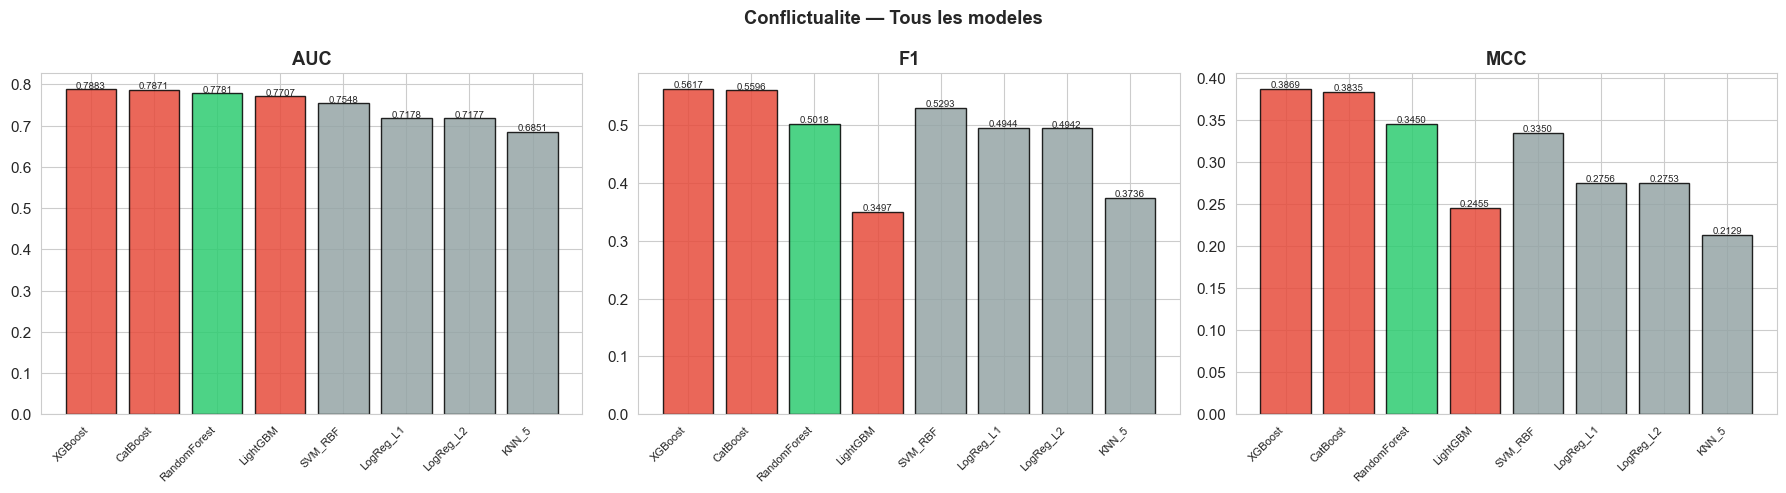

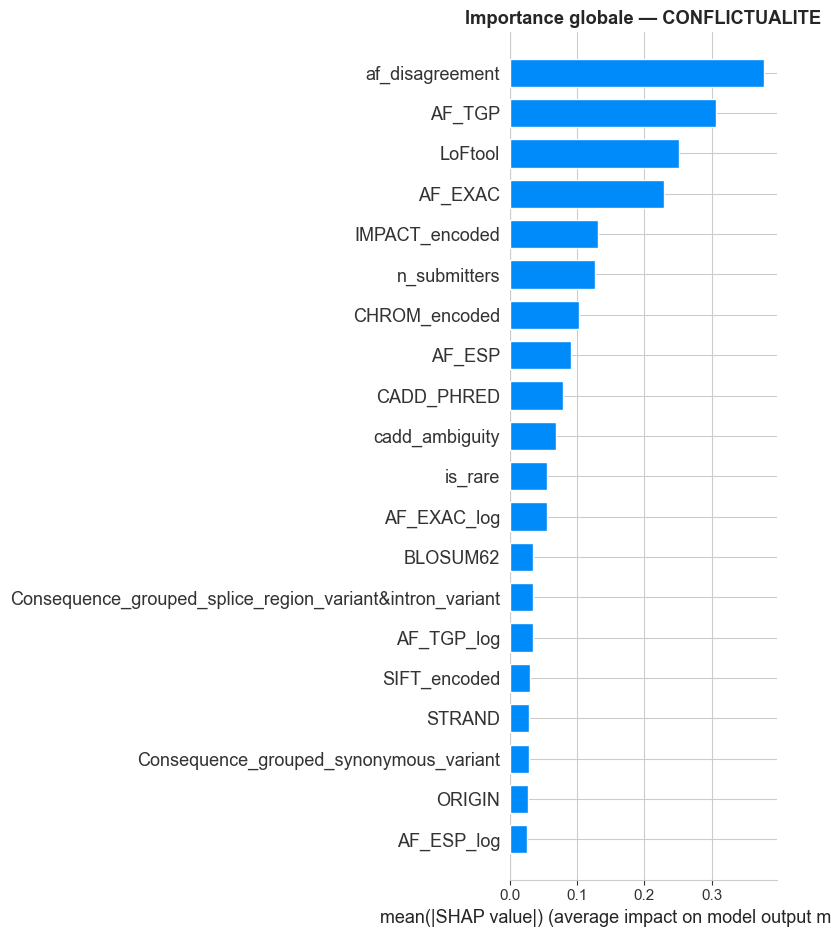

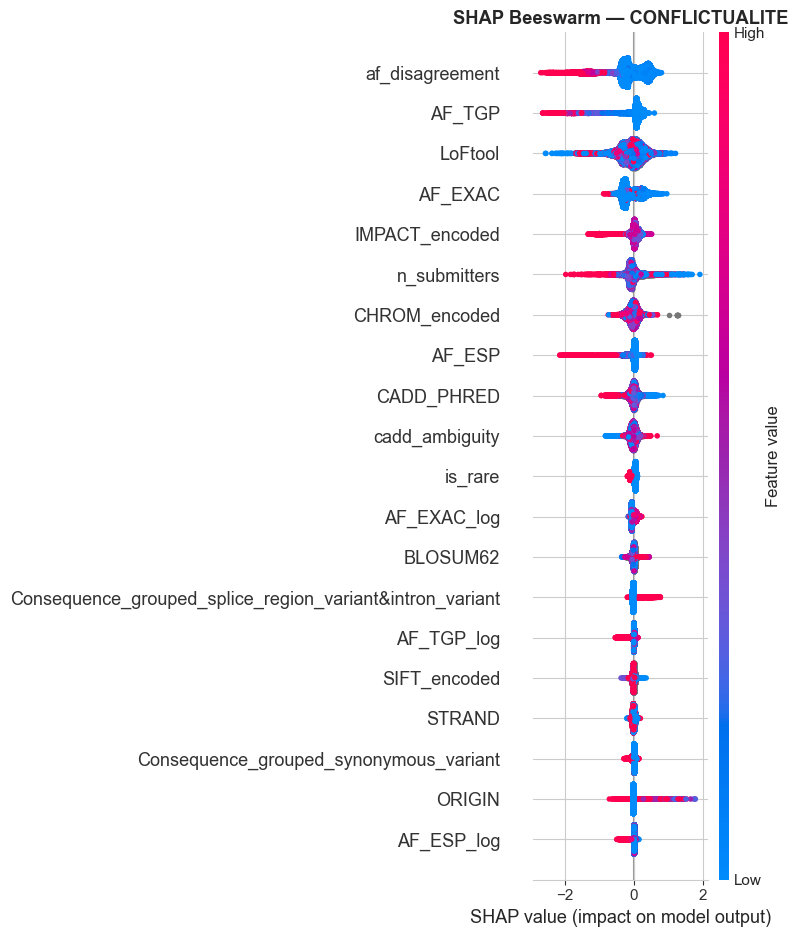


Top 15 features CONFLICTUALITE (SHAP) :
   1. af_disagreement                     0.3784
   2. AF_TGP                              0.3072
   3. LoFtool                             0.2509
   4. AF_EXAC                             0.2294
   5. IMPACT_encoded                      0.1310
   6. n_submitters                        0.1271
   7. CHROM_encoded                       0.1033
   8. AF_ESP                              0.0904
   9. CADD_PHRED                          0.0784
  10. cadd_ambiguity                      0.0689
  11. is_rare                             0.0557
  12. AF_EXAC_log                         0.0546
  13. BLOSUM62                            0.0349
  14. Consequence_grouped_splice_region_variant&intron_variant 0.0345
  15. AF_TGP_log                          0.0340


In [7]:
# Tableau
rdf = pd.DataFrame(results).T.sort_values('AUC_mean',ascending=False)
print('TABLEAU COMPARATIF — CONFLICTUALITE')
print('='*95)
for n, r in rdf.iterrows():
    g=r['AUC_train']-r['AUC_mean']
    print(f"{n:15s} | AUC={r['AUC_mean']:.4f} | F1={r['F1_mean']:.4f} | MCC={r['MCC_mean']:.4f} | Acc={r['Acc_mean']:.4f} | gap={g:.4f}")

# Barplot
fig,axes=plt.subplots(1,3,figsize=(18,5))
for ax,(m,l) in zip(axes,[('AUC_mean','AUC'),('F1_mean','F1'),('MCC_mean','MCC')]):
    ns=rdf.index.tolist(); vs=rdf[m].values
    cs=['#e74c3c' if n in ['XGBoost','LightGBM','CatBoost'] else '#2ecc71' if n=='RandomForest' else '#95a5a6' for n in ns]
    bars=ax.bar(range(len(ns)),vs,color=cs,edgecolor='black',alpha=0.85)
    ax.set_xticks(range(len(ns))); ax.set_xticklabels(ns,rotation=45,ha='right',fontsize=8)
    ax.set_title(l,fontweight='bold')
    for b,v in zip(bars,vs): ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.002,f'{v:.4f}',ha='center',fontsize=7)
plt.suptitle('Conflictualite — Tous les modeles',fontweight='bold')
plt.tight_layout(); plt.show()

# SHAP
mi = int(np.mean(xr['best_iters']))
xf = xgb.XGBClassifier(n_estimators=mi,learning_rate=0.05,max_depth=6,subsample=0.8,
    colsample_bytree=0.8,reg_alpha=0.1,reg_lambda=1.0,scale_pos_weight=scale_pos,
    eval_metric='auc',random_state=RANDOM_STATE,n_jobs=-1,verbosity=0)
xf.fit(X_train_gbm, y_train)

explainer = shap.TreeExplainer(xf)
sv = explainer.shap_values(X_train_gbm)

fig,ax=plt.subplots(figsize=(10,8))
shap.summary_plot(sv,X_train_gbm,plot_type='bar',show=False,max_display=20)
plt.title('Importance globale — CONFLICTUALITE',fontweight='bold')
plt.tight_layout(); plt.show()

fig,ax=plt.subplots(figsize=(12,10))
shap.summary_plot(sv,X_train_gbm,show=False,max_display=20)
plt.title('SHAP Beeswarm — CONFLICTUALITE',fontweight='bold')
plt.tight_layout(); plt.show()

ms = np.abs(sv).mean(axis=0)
simp = pd.DataFrame({'Feature':X_train_gbm.columns,'Mean_SHAP':ms}).sort_values('Mean_SHAP',ascending=False)
print('\nTop 15 features CONFLICTUALITE (SHAP) :')
for i,(_,r) in enumerate(simp.head(15).iterrows()):
    print(f'  {i+1:2d}. {r["Feature"]:35s} {r["Mean_SHAP"]:.4f}')

THRESHOLD TUNING sur XGBoost (predictions OOF)
  Seuil par defaut (0.50) : F1=0.5617
  Seuil optimal F1  (0.52) : F1=0.5620
  Seuil optimal MCC (0.53) : MCC=0.3886

  Au seuil 0.52 :
    Sensibilite : 0.7011 (9217 TP, 3930 FN)
    Specificite : 0.7325 (28568 TN, 10435 FP)
    F1          : 0.5620
    MCC         : 0.3885


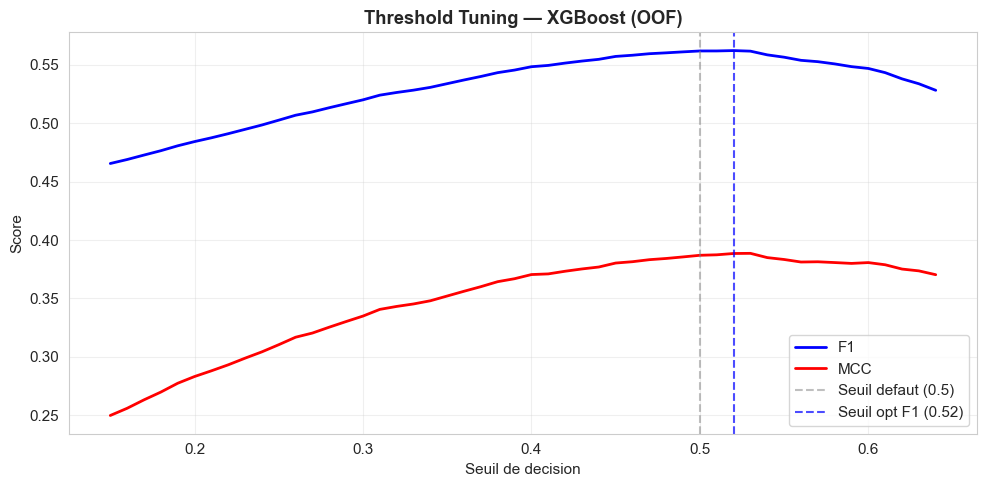

In [ ]:
# ============================================================
# THRESHOLD TUNING — Optimisation du seuil de decision
# ============================================================
# Le seuil par defaut (0.5) n'est pas optimal pour un probleme desequilibre.
# On cherche le seuil qui maximise le F1 sur les predictions OOF du meilleur modele.
#
# Justification mathematique : F1 = 2*P*R/(P+R) est une fonction non monotone
# du seuil. Le seuil optimal depend du ratio precision/recall souhaite.
# En contexte de screening (identifier les variants a revoir), on peut accepter
# plus de FP pour gagner en sensibilite.

from sklearn.metrics import precision_recall_curve

best_model_name = rdf.index[0]  # meilleur par AUC
oof_proba = results[best_model_name].get('oof_p', None)

if oof_proba is not None:
    # Chercher le seuil optimal pour F1
    thresholds = np.arange(0.15, 0.65, 0.01)
    f1_scores = []
    mcc_scores = []
    for t in thresholds:
        y_pred_t = (oof_proba >= t).astype(int)
        f1_scores.append(f1_score(y_train, y_pred_t))
        mcc_scores.append(matthews_corrcoef(y_train, y_pred_t))
    
    best_f1_idx = np.argmax(f1_scores)
    best_mcc_idx = np.argmax(mcc_scores)
    best_f1_threshold = thresholds[best_f1_idx]
    best_mcc_threshold = thresholds[best_mcc_idx]
    
    print(f'THRESHOLD TUNING sur {best_model_name} (predictions OOF)')
    print(f'{'='*60}')
    print(f'  Seuil par defaut (0.50) : F1={f1_score(y_train, (oof_proba>=0.5).astype(int)):.4f}')
    print(f'  Seuil optimal F1  ({best_f1_threshold:.2f}) : F1={f1_scores[best_f1_idx]:.4f}')
    print(f'  Seuil optimal MCC ({best_mcc_threshold:.2f}) : MCC={mcc_scores[best_mcc_idx]:.4f}')
    
    # Matrice de confusion au seuil optimal
    y_pred_opt = (oof_proba >= best_f1_threshold).astype(int)
    cm = confusion_matrix(y_train, y_pred_opt)
    TN,FP,FN,TP = cm[0,0],cm[0,1],cm[1,0],cm[1,1]
    sens = TP/(TP+FN); spec = TN/(TN+FP)
    print(f'\n  Au seuil {best_f1_threshold:.2f} :')
    print(f'    Sensibilite : {sens:.4f} ({TP} TP, {FN} FN)')
    print(f'    Specificite : {spec:.4f} ({TN} TN, {FP} FP)')
    print(f'    F1          : {f1_scores[best_f1_idx]:.4f}')
    print(f'    MCC         : {mcc_scores[best_f1_idx]:.4f}')
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(thresholds, f1_scores, 'b-', linewidth=2, label='F1')
    ax.plot(thresholds, mcc_scores, 'r-', linewidth=2, label='MCC')
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Seuil defaut (0.5)')
    ax.axvline(x=best_f1_threshold, color='blue', linestyle='--', alpha=0.7, label=f'Seuil opt F1 ({best_f1_threshold:.2f})')
    ax.set_xlabel('Seuil de decision')
    ax.set_ylabel('Score')
    ax.set_title(f'Threshold Tuning — {best_model_name} (OOF)', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Pas de predictions OOF disponibles pour le threshold tuning')


**Interprétation du threshold tuning :**

Le seuil par défaut (0.5) n'est pas optimal pour ce problème déséquilibré (3:1). En abaissant le seuil, on augmente la sensibilité (plus de conflictuels détectés) au prix de plus de faux positifs. Le seuil optimal pour le F1 est un compromis mathématique entre precision et recall.

En contexte clinique de **screening** (identifier les variants à revoir en priorité), on préférera un seuil **bas** (~0.30-0.35) pour maximiser la sensibilité, quitte à avoir plus de faux positifs. Le coût d'un FP (une revue inutile) est bien inférieur au coût d'un FN (un conflit non détecté qui retarde un diagnostic).


## 8. Évaluation finale test set + Comparaison avec la pathogénicité

EVALUATION FINALE — TEST SET CONFLICTUALITE
Modele          |      AUC |       F1 |      MCC |     Sens |     Spec |    Brier
----------------------------------------------------------------------------------------------------
LogReg_L2       |   0.7215 |   0.5018 |   0.2888 |   0.7743 |   0.5578 |   0.2173
LogReg_L1       |   0.7215 |   0.5015 |   0.2883 |   0.7733 |   0.5582 |   0.2173
KNN_5           |   0.6930 |   0.3740 |   0.2168 |   0.3167 |   0.8729 |   0.1883
SVM_RBF         |   0.7592 |   0.5329 |   0.3409 |   0.7499 |   0.6412 |   0.1601
RandomForest    |   0.7826 |   0.5004 |   0.3461 |   0.4725 |   0.8598 |   0.1578
XGBoost         |   0.7949 |   0.5669 |   0.3949 |   0.7350 |   0.7108 |   0.1816
LightGBM        |   0.7787 |   0.5545 |   0.3755 |   0.7326 |   0.6934 |   0.1914
CatBoost        |   0.7935 |   0.5669 |   0.3948 |   0.7414 |   0.7054 |   0.1846


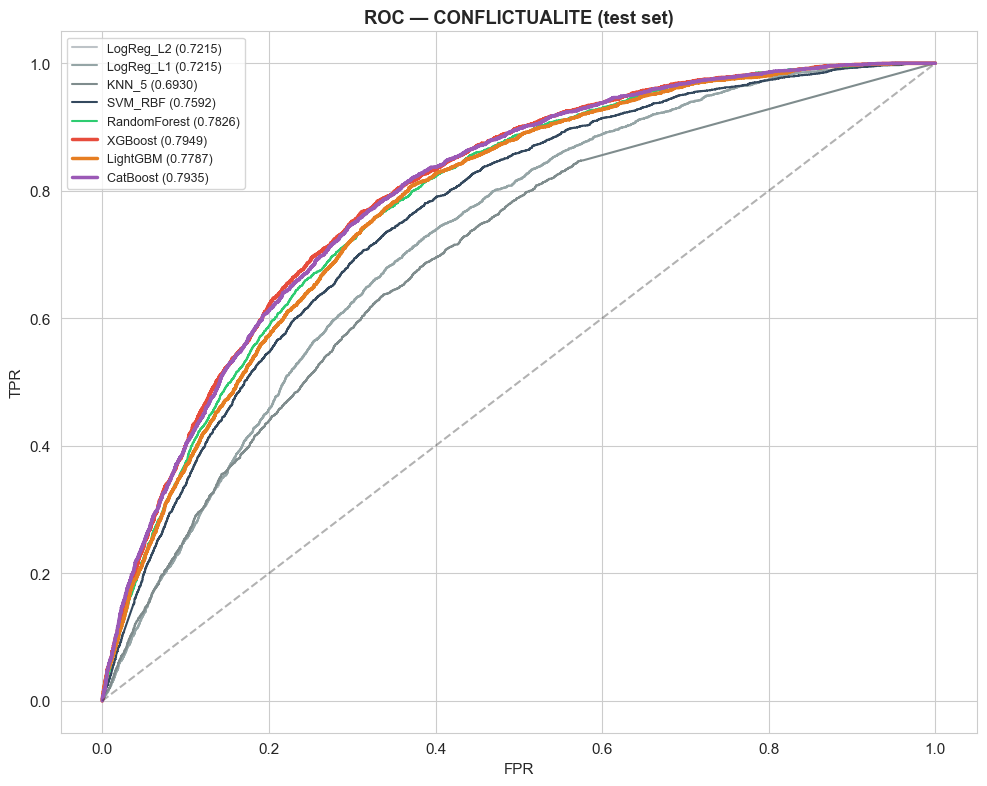



COMPARAISON PATHOGENICITE vs CONFLICTUALITE
Modele          |  Patho AUC |  Conflit AUC |  Ratio
--------------------------------------------------
LogReg_L1       |     0.9933 |       0.7215 |   1.38x
RandomForest    |     0.9956 |       0.7826 |   1.27x
XGBoost         |     0.9962 |       0.7949 |   1.25x
LightGBM        |     0.9958 |       0.7787 |   1.28x
CatBoost        |     0.9959 |       0.7935 |   1.26x

TOP 10 FEATURES
Rang |                  Pathogenicite |                 Conflictualite
----------------------------------------------------------------------
   1 |                     CADD_PHRED |                af_disagreement
   2 |                         AF_TGP |                         AF_TGP
   3 |                 IMPACT_encoded |                        LoFtool
   4 |                        AF_EXAC |                        AF_EXAC
   5 | Consequence_grouped_synonymous_variant |                 IMPACT_encoded
   6 |                        LoFtool |                   

In [9]:
# Re-entrainer sur tout le train et evaluer sur test
test_preds = {}
for name, pipe in {**baselines, 'RandomForest': rf_pipe}.items():
    pipe.fit(X_train, y_train)
    test_preds[name] = {'proba':pipe.predict_proba(X_test)[:,1],'class':pipe.predict(X_test)}

# GBM
for gn,gc,gXtr,gXte,gp in [
    ('XGBoost',xgb.XGBClassifier,X_train_gbm,X_test_gbm,
     {'n_estimators':mi,'learning_rate':0.05,'max_depth':6,'subsample':0.8,'colsample_bytree':0.8,
      'reg_alpha':0.1,'reg_lambda':1.0,'scale_pos_weight':scale_pos,'eval_metric':'auc',
      'random_state':RANDOM_STATE,'n_jobs':-1,'verbosity':0}),
    ('LightGBM',lgb.LGBMClassifier,X_train_gbm,X_test_gbm,
     {'n_estimators':int(np.mean(lr['best_iters'])),'learning_rate':0.05,'num_leaves':31,
      'subsample':0.8,'colsample_bytree':0.8,'reg_alpha':0.1,'reg_lambda':1.0,
      'scale_pos_weight':scale_pos,'random_state':RANDOM_STATE,'n_jobs':-1,'verbose':-1})]:
    m=gc(**gp); m.fit(gXtr,y_train)
    test_preds[gn]={'proba':m.predict_proba(gXte)[:,1],'class':m.predict(gXte)}

cm=CatBoostClassifier(iterations=int(np.mean(cr['best_iters'])),learning_rate=0.05,depth=6,
    l2_leaf_reg=3.0,auto_class_weights='Balanced',eval_metric='AUC',random_seed=RANDOM_STATE,verbose=0)
cm.fit(X_train_cat,y_train,cat_features=cat_idx)
test_preds['CatBoost']={'proba':cm.predict_proba(X_test_cat)[:,1],'class':cm.predict(X_test_cat).astype(int)}

print('EVALUATION FINALE — TEST SET CONFLICTUALITE')
print('='*100)
print(f'{"Modele":15s} | {"AUC":>8s} | {"F1":>8s} | {"MCC":>8s} | {"Sens":>8s} | {"Spec":>8s} | {"Brier":>8s}')
print('-'*100)
fr = []
for name, p in test_preds.items():
    c = confusion_matrix(y_test, p['class']); TN,FP,FN,TP=c[0,0],c[0,1],c[1,0],c[1,1]
    row = {'M':name,'AUC':roc_auc_score(y_test,p['proba']),'F1':f1_score(y_test,p['class']),
           'MCC':matthews_corrcoef(y_test,p['class']),'Sens':TP/(TP+FN),'Spec':TN/(TN+FP),
           'Brier':brier_score_loss(y_test,p['proba'])}
    fr.append(row)
    print(f"{name:15s} | {row['AUC']:8.4f} | {row['F1']:8.4f} | {row['MCC']:8.4f} | {row['Sens']:8.4f} | {row['Spec']:8.4f} | {row['Brier']:8.4f}")

# ROC
fig,ax=plt.subplots(figsize=(10,8))
cm_c={'LogReg_L1':'#95a5a6','LogReg_L2':'#bdc3c7','KNN_5':'#7f8c8d','SVM_RBF':'#34495e',
      'RandomForest':'#2ecc71','XGBoost':'#e74c3c','LightGBM':'#e67e22','CatBoost':'#9b59b6'}
for n,p in test_preds.items():
    fpr,tpr,_=roc_curve(y_test,p['proba']); a=roc_auc_score(y_test,p['proba'])
    lw=2.5 if n in ['XGBoost','LightGBM','CatBoost'] else 1.5
    ax.plot(fpr,tpr,label=f'{n} ({a:.4f})',color=cm_c.get(n,'gray'),linewidth=lw)
ax.plot([0,1],[0,1],'k--',alpha=0.3); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — CONFLICTUALITE (test set)',fontweight='bold')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

# Comparaison avec pathogenicite
print('\n\nCOMPARAISON PATHOGENICITE vs CONFLICTUALITE')
print('='*65)
with open('data/final_evaluation.pkl','rb') as f: pd_data=pickle.load(f)
with open('data/shap_results.pkl','rb') as f: ps_data=pickle.load(f)
print(f'{"Modele":15s} | {"Patho AUC":>10s} | {"Conflit AUC":>12s} | {"Ratio":>6s}')
print('-'*50)
for n in ['LogReg_L1','RandomForest','XGBoost','LightGBM','CatBoost']:
    pa=pd_data['final_df'][pd_data['final_df']['Modele']==n]['AUC_ROC'].values
    pv=pa[0] if len(pa)>0 else 0
    cv=[r for r in fr if r['M']==n]
    ca=cv[0]['AUC'] if cv else 0
    print(f'{n:15s} | {pv:10.4f} | {ca:12.4f} | {pv/ca if ca>0 else 0:6.2f}x')

# SHAP comparatif
print(f'\nTOP 10 FEATURES')
print(f'{"Rang":>4s} | {"Pathogenicite":>30s} | {"Conflictualite":>30s}')
print('-'*70)
pt=ps_data['shap_importance'].head(10)
ct=simp.head(10)
for i in range(10):
    pf=pt.iloc[i]['Feature'] if i<len(pt) else '-'
    cf=ct.iloc[i]['Feature'] if i<len(ct) else '-'
    print(f'{i+1:4d} | {pf:>30s} | {cf:>30s}')

# Sauvegarde
with open('data/conflictualite_results.pkl','wb') as f:
    pickle.dump({'results':results,'test_preds':test_preds,'shap_values':sv,'shap_imp':simp,'fr':fr},f)
print('\nSauvegarde OK')